In [1]:
# 1 Persiapan Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Library berhasil dimuat.")

Library berhasil dimuat.


In [2]:
# 2 Import Dataset

iris = load_iris(as_frame=True)
df = iris.frame
df['target_name'] = df['target'].map(dict(enumerate(iris.target_names)))

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# 3 Preprocessing (Eksplorasi Awal)

print(df.info())
print("\nJumlah data per kelas:")
print(df['target_name'].value_counts())

X = df[iris.feature_names]
y = df['target']

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None

Jumlah data per kelas:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [4]:
# 4 Training Model

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

print("Model berhasil dilatih pada", X_train.shape[0], "data latih.")

Model berhasil dilatih pada 120 data latih.


In [5]:
# 5 Evaluasi

y_pred = model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi model pada data uji: {akurasi:.2%}")

Akurasi model pada data uji: 100.00%


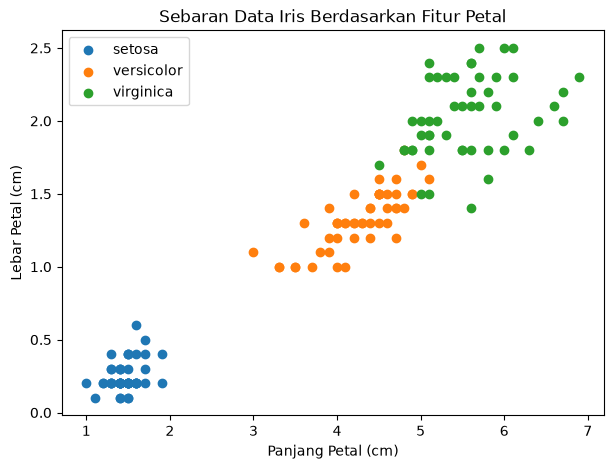

In [6]:
# 6 Visualisasi

plt.figure(figsize=(7, 5))
for target_value, target_name in enumerate(iris.target_names):
    subset = df[df['target'] == target_value]
    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=target_name
    )

plt.xlabel('Panjang Petal (cm)')
plt.ylabel('Lebar Petal (cm)')
plt.title('Sebaran Data Iris Berdasarkan Fitur Petal')
plt.legend()
plt.show()